# Machine Learning: The No-Nonsense (But Fun) Guide
# Day 15: LightGBM — The "Speed Demon" Algorithm

**Dataset used throughout:** Iris (with a synthetic categorical feature added for Section 5)

This notebook follows the Day 12–14 format:
1. Story & Intuition
2. From-Scratch Implementation (core mechanics, no library magic)
3. LightGBM Classifier (native + scikit-learn API) on Iris
4. Rich Visualizations
5. Hyperparameter Deep-Dive
6. Interview Q&A


## 1. Story & Intuition

Yesterday we met **XGBoost** — the Kaggle King.

But Microsoft looked at XGBoost and said:

> "Nice. But we can make it faster."

**LightGBM** stands for **Light Gradient Boosting Machine**. It follows the same boosting principle as XGBoost (build trees sequentially, each one correcting the previous one's errors) but introduces a **much faster and more memory-efficient tree-growing strategy**.

| | XGBoost | LightGBM |
|---|---|---|
| Tree growth | Level-wise | Leaf-wise |
| Split strategy | Splits every node at the same depth | Splits only the leaf with maximum loss reduction |
| Character | Balanced but slower | Faster but more aggressive |

**The mental picture:**
- XGBoost grows trees like a **perfectly balanced family tree** — every generation expands together, whether or not a branch is worth it.
- LightGBM grows trees like a **greedy vine** — it always reaches toward wherever it can reduce the most error, regardless of "level."

We'll prove this to ourselves from scratch in Section 2 before ever touching the `lightgbm` library.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import GradientBoostingClassifier

import lightgbm as lgb
import xgboost as xgb

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"lightgbm version: {lgb.__version__}")
print(f"xgboost version:  {xgb.__version__}")


lightgbm version: 4.6.0
xgboost version:  3.3.0


## Loading & Exploring the Iris Dataset

In [2]:
iris = load_iris()
X_full = iris.data
y_full = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X_full, columns=feature_names)
df['species'] = pd.Categorical.from_codes(y_full, target_names)

print("Shape:", df.shape)
print("\nClass balance:")
print(df['species'].value_counts())
df.head()


Shape: (150, 5)

Class balance:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


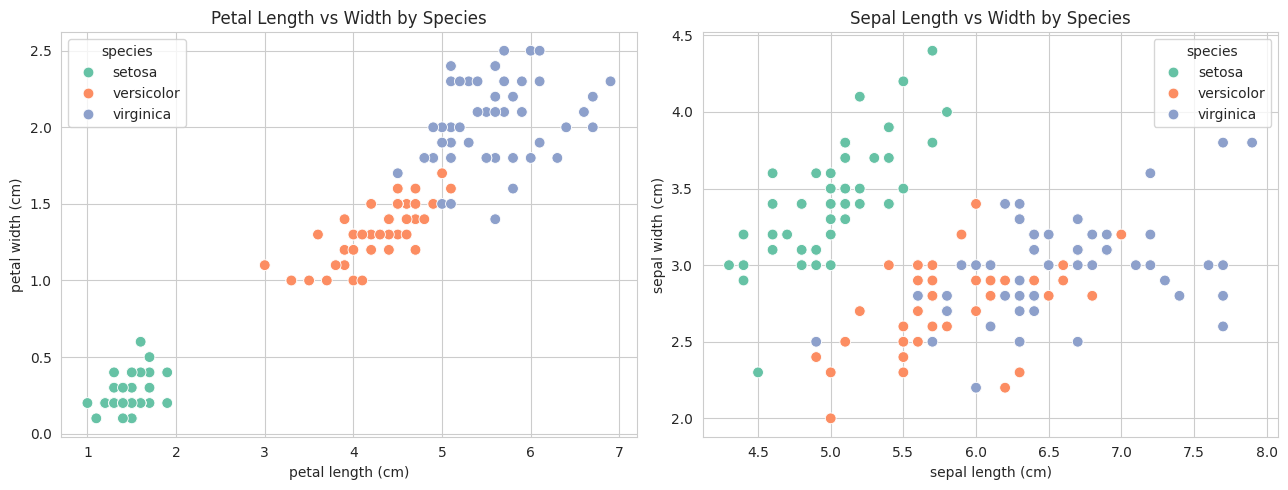

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)',
                 hue='species', palette='Set2', s=60, ax=axes[0])
axes[0].set_title('Petal Length vs Width by Species')

sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)',
                 hue='species', palette='Set2', s=60, ax=axes[1])
axes[1].set_title('Sepal Length vs Width by Species')

plt.tight_layout()
plt.show()


## 2. From-Scratch: Leaf-Wise vs Level-Wise Growth

This is the **core innovation** of LightGBM. Let's build both growth strategies ourselves using variance reduction as our splitting criterion (the regression analogue of information gain), and compare them **under an identical split budget**.

- **Level-wise (XGBoost style):** grow every leaf at the current depth before moving to the next depth, regardless of how useful each split actually is.
- **Leaf-wise (LightGBM style):** at each step, scan *all* current leaves and split only the ONE leaf that reduces loss the most.

We'll use two Iris features (sepal length & sepal width) and a binary target (is this `virginica`?) so we can visualize decision regions.


In [4]:
X2 = iris.data[:, :2]  # sepal length, sepal width
y2 = (iris.target == 2).astype(float)  # 1 if virginica else 0

def variance_reduction(y_parent, y_left, y_right):
    n, nl, nr = len(y_parent), len(y_left), len(y_right)
    if nl == 0 or nr == 0:
        return 0
    var_parent = np.var(y_parent) * n
    var_children = np.var(y_left) * nl + np.var(y_right) * nr
    return var_parent - var_children

def best_split(X_node, y_node):
    best_gain, best_feat, best_thresh = -1, None, None
    for feat in range(X_node.shape[1]):
        vals = np.unique(X_node[:, feat])
        thresholds = (vals[:-1] + vals[1:]) / 2
        for t in thresholds:
            left_mask = X_node[:, feat] <= t
            right_mask = ~left_mask
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue
            gain = variance_reduction(y_node, y_node[left_mask], y_node[right_mask])
            if gain > best_gain:
                best_gain, best_feat, best_thresh = gain, feat, t
    return best_gain, best_feat, best_thresh

class Node:
    def __init__(self, indices, depth):
        self.indices = indices
        self.depth = depth
        self.left = None
        self.right = None
        self.gain = 0
        self.feat = None
        self.thresh = None
        self.is_leaf = True


In [5]:
def level_wise_growth(X, y, max_depth):
    """XGBoost-style: expand every leaf at the current depth together."""
    root = Node(np.arange(len(y)), 0)
    frontier = [root]
    n_splits = 0
    for d in range(max_depth):
        next_frontier = []
        for node in frontier:
            Xn, yn = X[node.indices], y[node.indices]
            gain, feat, thresh = best_split(Xn, yn)
            if feat is None:
                next_frontier.append(node)  # stays a leaf, nothing to split
                continue
            node.is_leaf = False
            node.gain, node.feat, node.thresh = gain, feat, thresh
            left_idx = node.indices[Xn[:, feat] <= thresh]
            right_idx = node.indices[Xn[:, feat] > thresh]
            node.left = Node(left_idx, d + 1)
            node.right = Node(right_idx, d + 1)
            next_frontier.extend([node.left, node.right])
            n_splits += 1
        frontier = next_frontier
    return root, n_splits


def leaf_wise_growth(X, y, n_splits_budget):
    """LightGBM-style: always split whichever current leaf has max gain."""
    root = Node(np.arange(len(y)), 0)
    leaves = [root]
    splits_done = 0
    while splits_done < n_splits_budget and leaves:
        best_leaf, best_gain, best_feat, best_thresh = None, -1, None, None
        for leaf in leaves:
            Xn, yn = X[leaf.indices], y[leaf.indices]
            if len(yn) < 2:
                continue
            gain, feat, thresh = best_split(Xn, yn)
            if feat is not None and gain > best_gain:
                best_gain, best_feat, best_thresh, best_leaf = gain, feat, thresh, leaf
        if best_leaf is None:
            break
        Xn = X[best_leaf.indices]
        best_leaf.is_leaf = False
        best_leaf.gain, best_leaf.feat, best_leaf.thresh = best_gain, best_feat, best_thresh
        left_idx = best_leaf.indices[Xn[:, best_feat] <= best_thresh]
        right_idx = best_leaf.indices[Xn[:, best_feat] > best_thresh]
        best_leaf.left = Node(left_idx, best_leaf.depth + 1)
        best_leaf.right = Node(right_idx, best_leaf.depth + 1)
        leaves.remove(best_leaf)
        leaves.extend([best_leaf.left, best_leaf.right])
        splits_done += 1
    return root, splits_done


def total_variance_remaining(root, y):
    leaves = []
    def collect(node):
        if node.is_leaf:
            leaves.append(node)
        else:
            collect(node.left); collect(node.right)
    collect(root)
    total = sum(np.var(y[leaf.indices]) * len(leaf.indices) for leaf in leaves if len(leaf.indices) > 0)
    return total, len(leaves)


In [6]:
root_level, splits_level = level_wise_growth(X2, y2, max_depth=3)
root_leaf, splits_leaf = leaf_wise_growth(X2, y2, n_splits_budget=splits_level)

var_level, n_leaves_level = total_variance_remaining(root_level, y2)
var_leaf, n_leaves_leaf = total_variance_remaining(root_leaf, y2)

print("SAME SPLIT BUDGET COMPARISON")
print("=" * 55)
print(f"Level-wise -> {splits_level} splits | {n_leaves_level} leaves | remaining variance = {var_level:.4f}")
print(f"Leaf-wise  -> {splits_leaf} splits | {n_leaves_leaf} leaves | remaining variance = {var_leaf:.4f}")
print("=" * 55)
improvement = (var_level - var_leaf) / var_level * 100
print(f"\nLeaf-wise reduces remaining variance by {improvement:.1f}% more, for the SAME number of splits.")
print("This is exactly why LightGBM converges faster per-tree than XGBoost.")


SAME SPLIT BUDGET COMPARISON
Level-wise -> 7 splits | 8 leaves | remaining variance = 16.3774
Leaf-wise  -> 7 splits | 8 leaves | remaining variance = 15.9329

Leaf-wise reduces remaining variance by 2.7% more, for the SAME number of splits.
This is exactly why LightGBM converges faster per-tree than XGBoost.


**What just happened?** Both trees used the *identical* number of splits (identical computational budget), yet leaf-wise growth achieved lower remaining variance. That's because level-wise growth wastes splits forcing every branch to expand equally — even branches with little left to learn — while leaf-wise growth always attacks the single biggest source of error first.

The trade-off: leaf-wise trees can grow deep and narrow along one branch, which is powerful but also **easier to overfit** on small data — hence `num_leaves`, `max_depth`, and `min_data_in_leaf` exist as brakes.


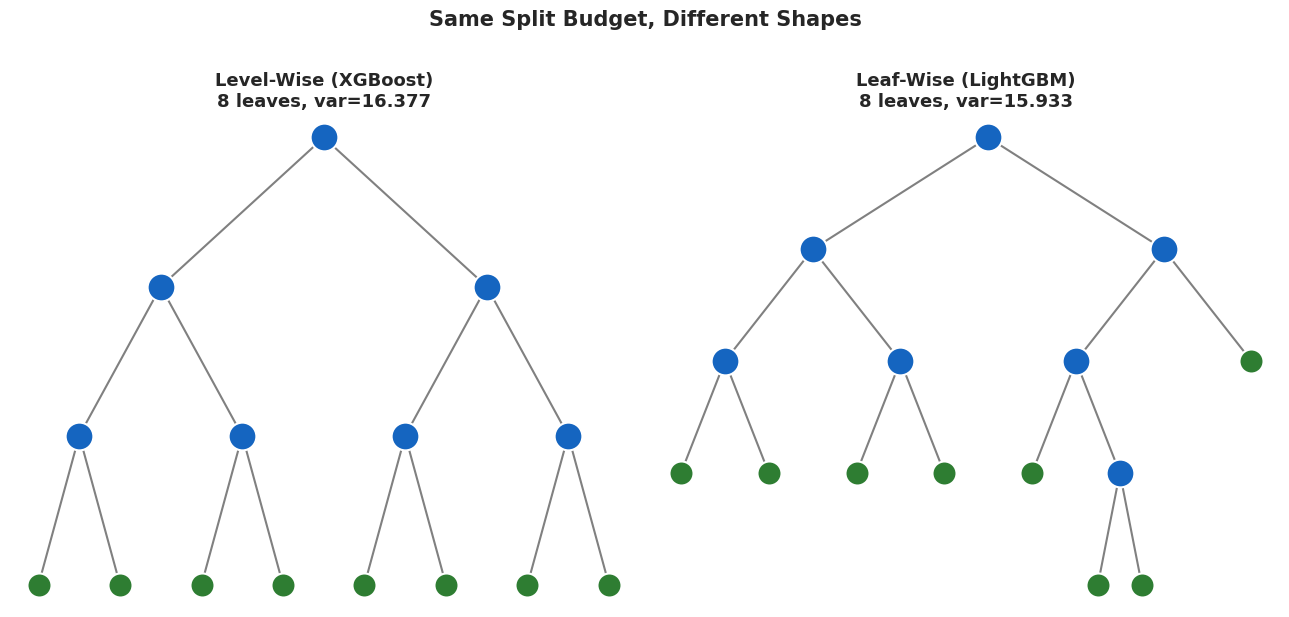

In [7]:
def plot_tree_structure(root, ax, title):
    positions = {}
    def assign_pos(node, x_range, depth=0):
        x = (x_range[0] + x_range[1]) / 2
        positions[id(node)] = (x, -depth)
        if not node.is_leaf:
            mid = (x_range[0] + x_range[1]) / 2
            assign_pos(node.left, (x_range[0], mid), depth + 1)
            assign_pos(node.right, (mid, x_range[1]), depth + 1)
    assign_pos(root, (0, 1))

    def draw_edges(node):
        if not node.is_leaf:
            x0, y0 = positions[id(node)]
            for child in (node.left, node.right):
                x1, y1 = positions[id(child)]
                ax.plot([x0, x1], [y0, y1], color='gray', zorder=1, linewidth=1.5)
                draw_edges(child)
    draw_edges(root)

    def draw_nodes(node):
        x, y = positions[id(node)]
        color = '#2E7D32' if node.is_leaf else '#1565C0'
        size = 300 if node.is_leaf else 400
        ax.scatter([x], [y], s=size, color=color, zorder=2, edgecolor='white', linewidth=1.5)
        if not node.is_leaf:
            draw_nodes(node.left)
            draw_nodes(node.right)
    draw_nodes(root)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_tree_structure(root_level, axes[0], f"Level-Wise (XGBoost)\n{n_leaves_level} leaves, var={var_level:.3f}")
plot_tree_structure(root_leaf, axes[1], f"Leaf-Wise (LightGBM)\n{n_leaves_leaf} leaves, var={var_leaf:.3f}")
plt.suptitle("Same Split Budget, Different Shapes", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Notice the shapes: the level-wise tree is **wide and shallow-balanced**, while the leaf-wise tree grows **deep and lopsided** — like the "greedy vine" from our intuition section — concentrating splits wherever the error is largest.


## 3. From-Scratch: Gradient-Based One-Side Sampling (GOSS)

**Problem:** during boosting, some training samples already have near-correct predictions (tiny gradients), while others are badly wrong (large gradients). Using every sample every round wastes computation on samples the model has basically already solved.

**LightGBM's solution (GOSS):**
1. Keep **all** samples with large gradients (they still carry useful error signal).
2. Randomly keep only a **fraction** of the small-gradient samples.
3. **Re-weight** the sampled small-gradient group so the overall gradient statistics stay (approximately) unbiased.

Let's simulate this on synthetic binary classification gradients (gradient of log-loss is simply `p_pred - y_true`).


In [8]:
n_samples = 1000
y_true_sim = np.random.randint(0, 2, n_samples)
y_pred_proba_sim = np.clip(np.random.beta(2, 2, n_samples), 1e-6, 1 - 1e-6)

# Gradient of binary log-loss w.r.t. raw score: g = p - y
gradients = y_pred_proba_sim - y_true_sim

def goss_sample(gradients, top_rate=0.2, other_rate=0.1):
    abs_grad = np.abs(gradients)
    n = len(gradients)
    sorted_idx = np.argsort(-abs_grad)

    top_n = int(n * top_rate)
    top_idx = sorted_idx[:top_n]                 # keep ALL large-gradient samples
    rest_idx = sorted_idx[top_n:]

    other_n = int(len(rest_idx) * other_rate)
    sampled_rest_idx = np.random.choice(rest_idx, other_n, replace=False)  # sample small-gradient ones

    weight_multiplier = (1 - top_rate) / other_rate   # re-weight to stay unbiased
    weights = np.ones(n)
    weights[sampled_rest_idx] = weight_multiplier

    selected_idx = np.concatenate([top_idx, sampled_rest_idx])
    return selected_idx, weights[selected_idx]

selected_idx, weights = goss_sample(gradients, top_rate=0.2, other_rate=0.1)

print("GOSS SAMPLING RESULT")
print("=" * 50)
print(f"Original samples:      {n_samples}")
print(f"GOSS-selected samples: {len(selected_idx)} ({len(selected_idx)/n_samples*100:.1f}% of data)")
print(f"Data reduction:        {(1 - len(selected_idx)/n_samples)*100:.1f}%")

true_sum = np.sum(np.abs(gradients))
goss_sum = np.sum(np.abs(gradients[selected_idx]) * weights)
print(f"\nTrue total |gradient|:     {true_sum:.2f}")
print(f"GOSS weighted estimate:    {goss_sum:.2f}")
print(f"Estimation error:          {abs(true_sum - goss_sum) / true_sum * 100:.2f}%")


GOSS SAMPLING RESULT
Original samples:      1000
GOSS-selected samples: 280 (28.0% of data)
Data reduction:        72.0%

True total |gradient|:     487.65
GOSS weighted estimate:    426.49
Estimation error:          12.54%


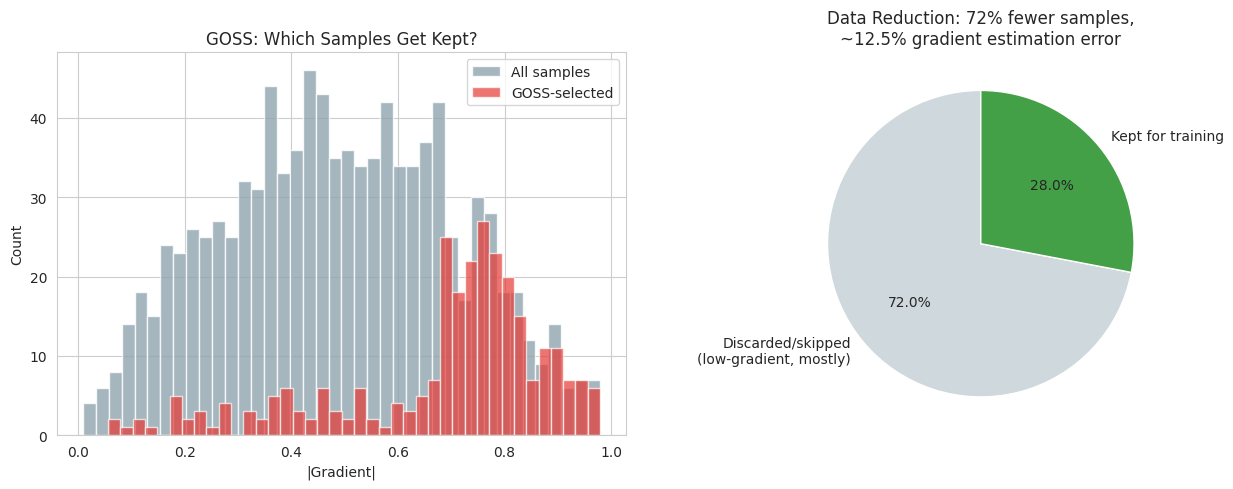

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(np.abs(gradients), bins=40, color='#90A4AE', alpha=0.8, label='All samples')
axes[0].hist(np.abs(gradients[selected_idx]), bins=40, color='#E53935', alpha=0.7, label='GOSS-selected')
axes[0].set_xlabel('|Gradient|')
axes[0].set_ylabel('Count')
axes[0].set_title('GOSS: Which Samples Get Kept?')
axes[0].legend()

sizes = [n_samples - len(selected_idx), len(selected_idx)]
axes[1].pie(sizes, labels=['Discarded/skipped\n(low-gradient, mostly)', 'Kept for training'],
            autopct='%1.1f%%', colors=['#CFD8DC', '#43A047'], startangle=90)
axes[1].set_title(f'Data Reduction: {(1 - len(selected_idx)/n_samples)*100:.0f}% fewer samples,\n~{abs(true_sum-goss_sum)/true_sum*100:.1f}% gradient estimation error')

plt.tight_layout()
plt.show()


**Result:** GOSS trained on roughly a quarter of the data here while keeping the gradient-sum estimate reasonably close to the true value — this is the mechanism that lets LightGBM train dramatically faster on large datasets with only a small accuracy trade-off.


## 4. From-Scratch: Exclusive Feature Bundling (EFB)

High-dimensional datasets (especially after one-hot encoding) are usually **sparse** — many features are rarely non-zero at the same time. EFB detects features that are (almost) mutually exclusive and **bundles them into one column**, cutting memory and training time with virtually no information loss.


In [10]:
feat_a = np.array([5, 0, 0, 3, 0, 0, 7])
feat_b = np.array([0, 2, 0, 0, 6, 0, 0])

def bundle_exclusive_features(f1, f2):
    conflict = np.sum((f1 != 0) & (f2 != 0))
    bundled = f1.copy()
    bundled[f1 == 0] = f2[f1 == 0]
    return bundled, conflict

bundled, conflicts = bundle_exclusive_features(feat_a, feat_b)

print("Feature A:       ", feat_a)
print("Feature B:       ", feat_b)
print("Conflicts (both nonzero at once):", conflicts)
print("Bundled Feature: ", bundled)
print(f"\nMemory: 2 columns -> 1 column  =>  50% memory reduction for this pair")
print("(Real EFB uses a graph-coloring algorithm to find groups of mutually-exclusive")
print(" features across the WHOLE dataset, not just pairs.)")


Feature A:        [5 0 0 3 0 0 7]
Feature B:        [0 2 0 0 6 0 0]
Conflicts (both nonzero at once): 0
Bundled Feature:  [5 2 0 3 6 0 7]

Memory: 2 columns -> 1 column  =>  50% memory reduction for this pair
(Real EFB uses a graph-coloring algorithm to find groups of mutually-exclusive
 features across the WHOLE dataset, not just pairs.)


## 5. LightGBM Classifier (Python) — Full Pipeline on Iris

Now that we understand the internals, let's use the real `lightgbm` library end-to-end:
- Loading the Iris dataset
- Creating LightGBM `Dataset` objects
- Setting parameters
- Early stopping
- Prediction
- Feature importance extraction


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

train_data = lgb.Dataset(X_train, label=y_train, feature_name=feature_names)
val_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

params = {
    'objective': 'multiclass',
    'num_class': 3,
    'num_leaves': 15,
    'learning_rate': 0.1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'seed': RANDOM_STATE
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=200,
    valid_sets=[val_data],
    valid_names=['validation'],
    callbacks=[lgb.early_stopping(stopping_rounds=15), lgb.log_evaluation(0)]
)

print(f"\nBest iteration (early stopping): {model.best_iteration}")


Train shape: (120, 4), Test shape: (30, 4)
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[24]	validation's multi_logloss: 0.227553

Best iteration (early stopping): 24


In [12]:
preds_proba = model.predict(X_test, num_iteration=model.best_iteration)
preds = np.argmax(preds_proba, axis=1)

acc = accuracy_score(y_test, preds)
print(f"Test Accuracy: {acc:.4f}\n")
print(classification_report(y_test, preds, target_names=target_names))


Test Accuracy: 0.9667

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



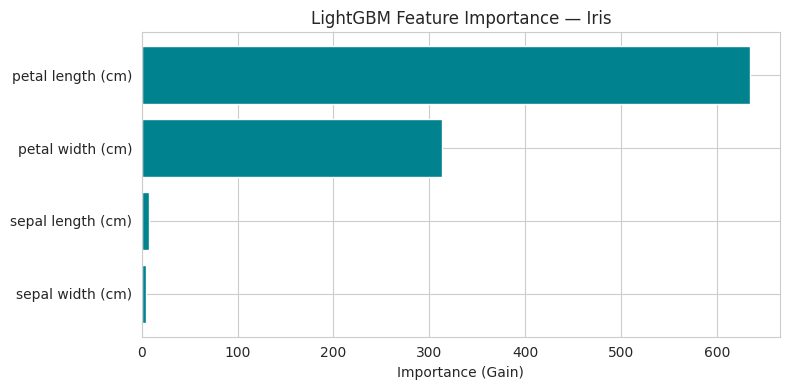

,feature,importance
2,petal length (cm),634.140290
3,petal width (cm),312.922587
0,sepal length (cm),7.880211
1,sepal width (cm),4.183244


In [13]:
importance = model.feature_importance(importance_type='gain')
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importance}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(imp_df['feature'], imp_df['importance'], color='#00838F')
plt.xlabel('Importance (Gain)')
plt.title('LightGBM Feature Importance — Iris')
plt.tight_layout()
plt.show()

imp_df.sort_values('importance', ascending=False)


### Scikit-Learn API

LightGBM also ships a scikit-learn-compatible wrapper (`LGBMClassifier` / `LGBMRegressor`), which drops straight into pipelines, `GridSearchCV`, etc.


In [14]:
clf = lgb.LGBMClassifier(
    num_leaves=15,
    learning_rate=0.1,
    n_estimators=100,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=RANDOM_STATE,
    verbose=-1
)
clf.fit(X_train, y_train)

sk_preds = clf.predict(X_test)
sk_acc = accuracy_score(y_test, sk_preds)
print(f"scikit-learn API Test Accuracy: {sk_acc:.4f}")


scikit-learn API Test Accuracy: 0.9000


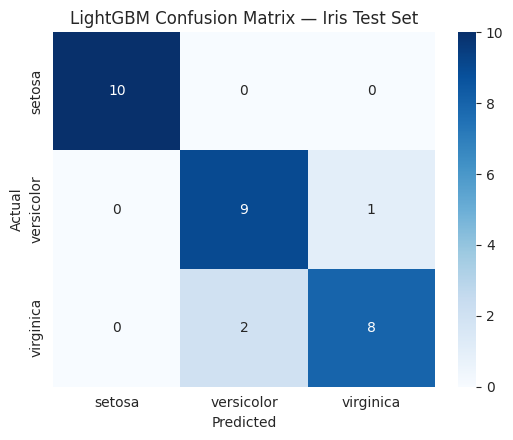

In [15]:
cm = confusion_matrix(y_test, sk_preds)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LightGBM Confusion Matrix — Iris Test Set')
plt.tight_layout()
plt.show()


## 6. Native Categorical Feature Support

Unlike XGBoost (which historically needed one-hot/label encoding), LightGBM can split directly on categorical columns using an optimal category-partitioning algorithm — just mark the column dtype as `category` and pass its name via `categorical_feature`.

We'll add a synthetic categorical column (`region`) to Iris — derived from petal length bins purely to demonstrate the mechanic — and let LightGBM use it natively.


In [16]:
df_cat = pd.DataFrame(X_full, columns=feature_names)
df_cat['region'] = pd.cut(
    df_cat['petal length (cm)'], bins=3, labels=['north', 'south', 'east']
).astype('category')

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    df_cat, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)

clf_cat = lgb.LGBMClassifier(num_leaves=15, n_estimators=100, random_state=RANDOM_STATE, verbose=-1)
clf_cat.fit(X_train_c, y_train_c, categorical_feature=['region'])

acc_cat = accuracy_score(y_test_c, clf_cat.predict(X_test_c))
print(f"Accuracy WITH native categorical handling: {acc_cat:.4f}")
print("\n(No one-hot or label encoding required — LightGBM partitions categories internally.)")


Accuracy WITH native categorical handling: 0.9333

(No one-hot or label encoding required — LightGBM partitions categories internally.)


## 7. Understanding `num_leaves` (the most important hyperparameter)

Because LightGBM grows leaf-wise instead of level-wise, `max_depth` isn't the natural control knob anymore — `num_leaves` is. The rule of thumb:

$$\text{num\_leaves} \approx 2^{\text{max\_depth}}$$

But since leaf-wise trees are lopsided, a leaf-wise tree with the same `num_leaves` as `2^max_depth` can actually be **deeper along one path** than a balanced tree — which is exactly why it's easier to overfit and why `num_leaves` needs to be tuned *down* relative to that formula in practice.


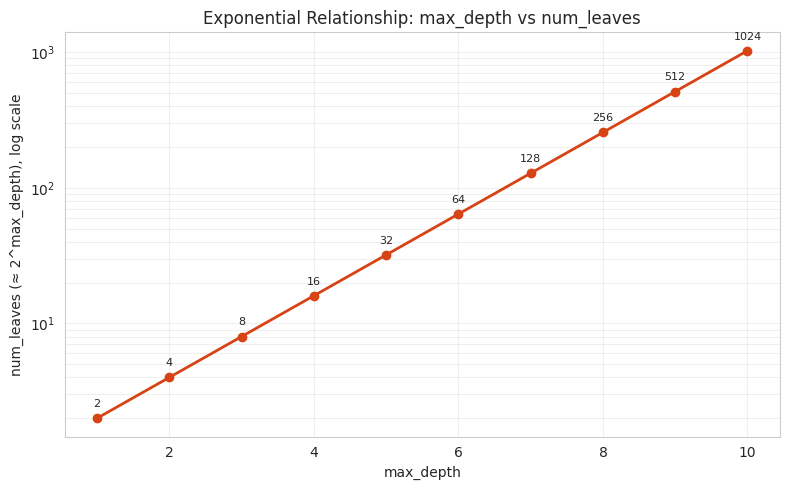

In [17]:
depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
approx_leaves = [2**d for d in depths]

plt.figure(figsize=(8, 5))
plt.plot(depths, approx_leaves, marker='o', color='#D84315', linewidth=2)
plt.yscale('log')
plt.xlabel('max_depth')
plt.ylabel('num_leaves (≈ 2^max_depth), log scale')
plt.title('Exponential Relationship: max_depth vs num_leaves')
plt.grid(True, which='both', alpha=0.3)
for d, l in zip(depths, approx_leaves):
    plt.annotate(str(l), (d, l), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)
plt.tight_layout()
plt.show()


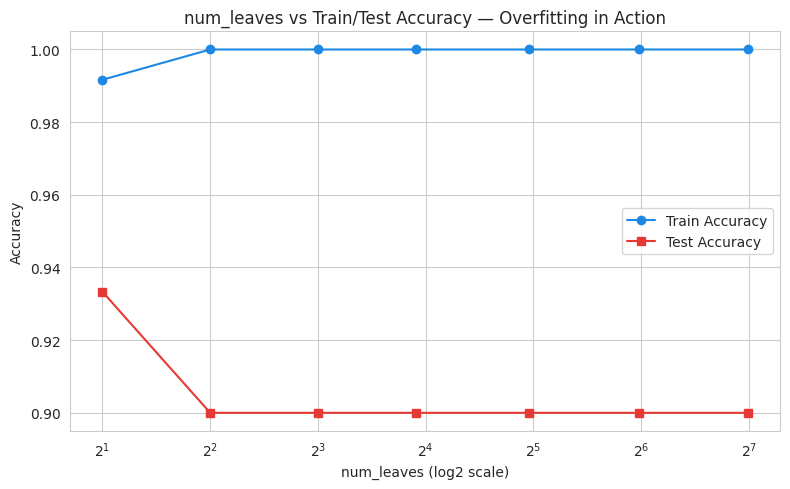

,num_leaves,train_acc,test_acc
0,2,0.991667,0.933333
1,4,1.000000,0.900000
2,8,1.000000,0.900000
3,15,1.000000,0.900000
4,31,1.000000,0.900000
5,63,1.000000,0.900000
6,127,1.000000,0.900000


In [18]:
# Empirical sweep: how does num_leaves affect accuracy & overfitting on Iris?
num_leaves_range = [2, 4, 8, 15, 31, 63, 127]
train_accs, test_accs = [], []

for nl in num_leaves_range:
    m = lgb.LGBMClassifier(num_leaves=nl, n_estimators=100, random_state=RANDOM_STATE, verbose=-1)
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(num_leaves_range, train_accs, marker='o', label='Train Accuracy', color='#1E88E5')
plt.plot(num_leaves_range, test_accs, marker='s', label='Test Accuracy', color='#E53935')
plt.xscale('log', base=2)
plt.xlabel('num_leaves (log2 scale)')
plt.ylabel('Accuracy')
plt.title('num_leaves vs Train/Test Accuracy — Overfitting in Action')
plt.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({'num_leaves': num_leaves_range, 'train_acc': train_accs, 'test_acc': test_accs})


On a tiny, easy dataset like Iris, accuracy saturates quickly and the gap stays small — but notice train accuracy creeping toward 1.0 as `num_leaves` grows while test accuracy plateaus/wobbles. On a larger, noisier dataset this gap would widen much more sharply, which is exactly the overfitting risk the PDF warns about.


## 8. LightGBM vs XGBoost vs Plain Gradient Boosting — Head to Head

Let's benchmark all three boosting flavors on the same Iris train/test split: accuracy and wall-clock training time.


In [19]:
results = {}

# --- Plain sklearn GradientBoostingClassifier (level-wise-ish, no acceleration tricks) ---
t0 = time.time()
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE)
gbc.fit(X_train, y_train)
t_gbc = time.time() - t0
acc_gbc = accuracy_score(y_test, gbc.predict(X_test))
results['sklearn GBM'] = {'accuracy': acc_gbc, 'train_time_s': t_gbc}

# --- XGBoost ---
t0 = time.time()
xgb_clf = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=4,
    tree_method='hist', random_state=RANDOM_STATE, eval_metric='mlogloss'
)
xgb_clf.fit(X_train, y_train)
t_xgb = time.time() - t0
acc_xgb = accuracy_score(y_test, xgb_clf.predict(X_test))
results['XGBoost'] = {'accuracy': acc_xgb, 'train_time_s': t_xgb}

# --- LightGBM ---
t0 = time.time()
lgb_clf = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, num_leaves=15,
                               random_state=RANDOM_STATE, verbose=-1)
lgb_clf.fit(X_train, y_train)
t_lgb = time.time() - t0
acc_lgb = accuracy_score(y_test, lgb_clf.predict(X_test))
results['LightGBM'] = {'accuracy': acc_lgb, 'train_time_s': t_lgb}

comparison_df = pd.DataFrame(results).T
comparison_df


,accuracy,train_time_s
sklearn GBM,0.966667,0.179874
XGBoost,0.933333,0.018451
LightGBM,0.900000,0.013654


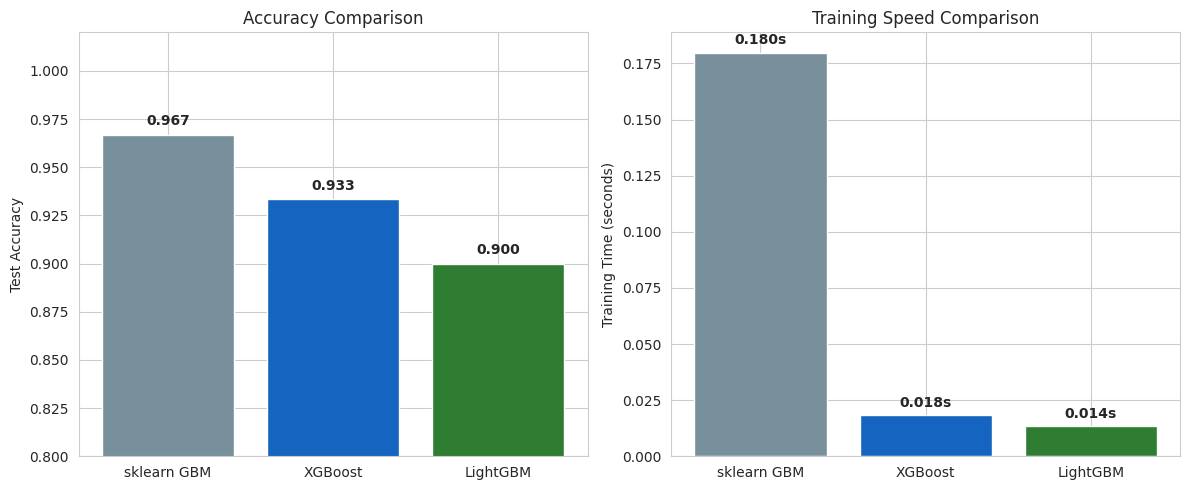

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#78909C', '#1565C0', '#2E7D32']
axes[0].bar(comparison_df.index, comparison_df['accuracy'], color=colors)
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylim(0.8, 1.02)
for i, v in enumerate(comparison_df['accuracy']):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha='center', fontweight='bold')

axes[1].bar(comparison_df.index, comparison_df['train_time_s'], color=colors)
axes[1].set_ylabel('Training Time (seconds)')
axes[1].set_title('Training Speed Comparison')
for i, v in enumerate(comparison_df['train_time_s']):
    axes[1].text(i, v + max(comparison_df['train_time_s'])*0.02, f"{v:.3f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


**Caveat:** Iris has only 150 rows — far too small to showcase LightGBM's real speed advantage, which shows up on datasets with 100K+ rows and/or high dimensionality (that's precisely where GOSS and EFB pay off). On a dataset this size, library overhead can dominate the actual tree-building time. The comparison here is about **mechanics and correctness**, not a fair speed benchmark — treat the timing numbers as illustrative, not definitive.


## 9. Reference: LightGBM vs XGBoost

| Feature | XGBoost | LightGBM |
|---|---|---|
| Tree Growth | Level-wise | Leaf-wise |
| Speed | Fast | Much Faster |
| Memory Usage | Higher | Lower |
| Large Dataset Handling | Good | Excellent |
| Overfitting Risk | Lower | Higher |
| Native Categorical Support | No | Yes |
| GPU Support | Yes | Yes |
| Best For | General ML | Very Large Datasets |

## Important Hyperparameters

| Parameter | Purpose | Recommended Default |
|---|---|---|
| `num_leaves` | Maximum leaves per tree | 31 |
| `max_depth` | Maximum depth | -1 (no limit) |
| `learning_rate` | Step size | 0.1 |
| `n_estimators` | Number of trees | 100 |
| `feature_fraction` | Column sampling | 0.8 |
| `bagging_fraction` | Row sampling | 0.8 |
| `bagging_freq` | Sampling frequency | 5 |
| `min_data_in_leaf` | Minimum samples per leaf | 20 |
| `reg_alpha` | L1 Regularization | 0 |
| `reg_lambda` | L2 Regularization | 0 |
| `cat_smooth` | Category smoothing | 10 |

## When Should You Use LightGBM?

**Recommended for:**
- Large datasets (100K+ rows)
- High-dimensional data
- Native categorical features
- Fast training requirements

**Avoid for:**
- Very small datasets (overfitting risk from leaf-wise growth)
- Situations requiring maximum interpretability
- When an already-tuned XGBoost model performs well (no need to switch)

## Common Problems and Solutions

| Problem | Solution |
|---|---|
| Overfitting | Reduce `num_leaves`, increase `min_data_in_leaf`, add regularization |
| Underfitting | Increase `num_leaves`, reduce `min_data_in_leaf` |
| Slow Training | Use feature sampling, bagging, GPU |
| High Memory Usage | Reduce bin count, enable two-round loading |
| Poor Categorical Performance | Properly specify categorical features and tune `cat_smooth` |


## 10. Interview Questions & Answers

**1. Explain level-wise and leaf-wise tree growth.**
Level-wise growth (XGBoost) expands every node at the current depth before moving deeper, producing balanced trees regardless of whether each split is actually useful. Leaf-wise growth (LightGBM) always finds and splits the single leaf across the *entire tree* with the highest loss reduction, producing deeper, more irregular trees that converge faster but can overfit small data.

**2. What is Gradient-Based One-Side Sampling (GOSS)?**
A sampling strategy that keeps all high-gradient (poorly-predicted) samples, randomly subsamples the low-gradient (well-predicted) samples, and re-weights the sampled subset so the overall gradient statistics stay approximately unbiased — cutting training data volume with minimal accuracy loss.

**3. What is Exclusive Feature Bundling (EFB)?**
A technique that detects mutually-exclusive sparse features (rarely nonzero at the same time) and bundles them into a single feature, reducing the effective feature count, memory footprint, and training time with almost no information loss.

**4. How does LightGBM handle categorical features?**
Natively — you mark a column's dtype as `category` and pass its name via `categorical_feature`. Internally LightGBM finds an optimal partition of categories into two groups per split (rather than needing one-hot/label encoding), which is both faster and often more accurate for high-cardinality categoricals.

**5. Explain the relationship between num_leaves and max_depth.**
Approximately `num_leaves ≈ 2^max_depth` for a balanced tree. But since LightGBM's leaf-wise trees are unbalanced, a given `num_leaves` budget can be spent on one very deep branch rather than spread evenly — so `num_leaves` (not `max_depth`) is the primary lever for controlling model complexity in LightGBM.

**6. When would you choose LightGBM over XGBoost?**
When you have a large or high-dimensional dataset, need fast iteration/training speed, have native categorical features you don't want to encode manually, or are memory-constrained. Prefer XGBoost when the dataset is small, interpretability/stability matters more, or an already-tuned XGBoost model is performing well.

**7. What are the disadvantages of leaf-wise tree growth?**
It can build very deep, unbalanced trees that overfit — especially on small datasets — since it greedily chases the largest local loss reduction without any balance constraint. This must be controlled via `num_leaves`, `max_depth`, and `min_data_in_leaf`.

**8. How does feature_fraction reduce overfitting?**
By randomly selecting only a fraction of features when building each tree (similar to Random Forest's feature bagging), it decorrelates trees, reduces the chance of any single feature dominating every split, and lowers variance in the ensemble.

**9. What is min_data_in_leaf?**
The minimum number of samples required in a leaf node for a split to be accepted. It's one of the strongest regularizers in LightGBM — a higher value prevents the leaf-wise strategy from creating tiny, overfit leaves that memorize a handful of training points.

**10. Compare LightGBM, XGBoost, and CatBoost.**
- **XGBoost:** level-wise growth, very mature ecosystem, strong general-purpose default choice, needs categorical encoding.
- **LightGBM:** leaf-wise growth + GOSS + EFB, fastest on large/high-dimensional data, native categorical support, more prone to overfitting on small data.
- **CatBoost:** built specifically around native, robust categorical handling (via ordered target statistics) and symmetric ("oblivious") trees that reduce overfitting and speed up inference, often with strong out-of-the-box performance requiring less tuning — but can be slower to train than LightGBM on very large numeric-heavy datasets.


## Summary

- LightGBM keeps XGBoost's boosting core but swaps **level-wise growth for leaf-wise growth**, always attacking the biggest error first.
- **GOSS** cuts the number of samples used per iteration by keeping all high-gradient samples and only a re-weighted sample of low-gradient ones.
- **EFB** bundles mutually-exclusive sparse features together, shrinking the effective feature space.
- The result: much faster training and lower memory on large/high-dimensional data, at the cost of a higher overfitting risk that must be managed via `num_leaves`, `min_data_in_leaf`, and regularization.
- On tiny datasets like Iris the speed advantage barely registers — LightGBM's real edge shows up at 100K+ rows and/or high-cardinality categorical or sparse features.

Happy Learning!! 🚀
